# Airline Passenger Satisfaction — Univariate Analysis

This notebook examines one variable at a time to understand distributions, sample composition, missingness, and unusual values before any relationship or hypothesis testing. It uses the cleaned dataset while preserving the original source fields.

**Analysis conventions**

- Service summaries use the `_clean` rating fields, where undocumented zero ratings are treated as missing.
- Original zero-inclusive fields remain available for later sensitivity analysis.
- Delay outliers are retained. Histograms are limited to the 99th percentile for readability, while tables report the complete range.
- Delay and distance units are described as dataset units because the source codebook is unavailable.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/processed/airline_passenger_satisfaction_cleaned.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} passenger records and {df.shape[1]} columns from {DATA_PATH}")

Loaded 129,880 passenger records and 70 columns from /Users/nhanle/Desktop/DBA/Practice/airlines-passenger-satisfaction/data/processed/airline_passenger_satisfaction_cleaned.csv


## 1. Dataset overview

In [2]:
overview = pd.DataFrame({
    "Measure": ["Rows", "Columns", "Unique passenger IDs", "Duplicate rows", "Missing arrival delays"],
    "Value": [len(df), df.shape[1], df["passenger_id"].nunique(), df.duplicated().sum(), df["arrival_delay"].isna().sum()],
})
display(overview.style.format({"Value": "{:,}"}))

missing = df.isna().sum().loc[lambda x: x.gt(0)].sort_values(ascending=False)
display(Markdown("**Columns containing missing values after cleaning**"))
display(missing.rename("Missing count").to_frame().assign(Percent=lambda x: x["Missing count"] / len(df) * 100).style.format({"Missing count": "{:,}", "Percent": "{:.2f}%"}))

,Measure,Value
0,Rows,"129,880"
1,Columns,70
2,Unique passenger IDs,"129,880"
3,Duplicate rows,0
4,Missing arrival delays,393


**Columns containing missing values after cleaning**

,Missing count,Percent
time_convenience_rating_clean,"6,681",5.14%
online_booking_rating_clean,"5,682",4.37%
inflight_wifi_rating_clean,"3,916",3.02%
online_boarding_rating_clean,"3,080",2.37%
digital_experience_score_clean,"1,603",1.23%
legroom_rating_clean,598,0.46%
any_arrival_delay,393,0.30%
arrival_delay,393,0.30%
delay_change,393,0.30%
total_delay,393,0.30%


In [1]:
def annotate_bars(ax, total=None, horizontal=False):
    total = total or len(df)
    for patch in ax.patches:
        value = patch.get_width() if horizontal else patch.get_height()
        if not np.isfinite(value):
            continue
        label = f"{int(value):,}\n({value / total:.1%})"
        if horizontal:
            ax.text(value, patch.get_y() + patch.get_height()/2, f"  {label}", va="center", fontsize=8)
        else:
            ax.text(patch.get_x() + patch.get_width()/2, value, label, ha="center", va="bottom", fontsize=8)

def count_plot(ax, column, title, order=None, horizontal=False, color=None):
    counts = df[column].value_counts().reindex(order).dropna() if order else df[column].value_counts()
    if horizontal:
        sns.barplot(x=counts.values, y=counts.index, ax=ax, color=color or COLORS[0])
    else:
        sns.barplot(x=counts.index, y=counts.values, ax=ax, color=color or COLORS[0])
        ax.tick_params(axis="x", rotation=20)
    ax.set_title(title)
    ax.set_xlabel("Passengers" if horizontal else "")
    ax.set_ylabel("" if horizontal else "Passengers")
    annotate_bars(ax, horizontal=horizontal)

## 2. Overall satisfaction

The target variable is binary: `Satisfied` versus the combined `Neutral or Dissatisfied` category.

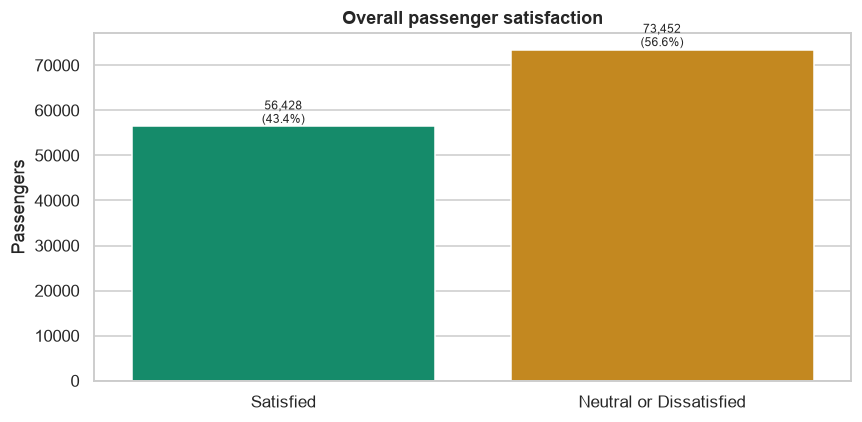

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ["Satisfied", "Neutral or Dissatisfied"]
counts = df["satisfaction"].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=[COLORS[2], COLORS[1]], legend=False, ax=ax)
ax.set(title="Overall passenger satisfaction", xlabel="", ylabel="Passengers")
annotate_bars(ax)
plt.tight_layout()
plt.show()

## 3. Passenger characteristics

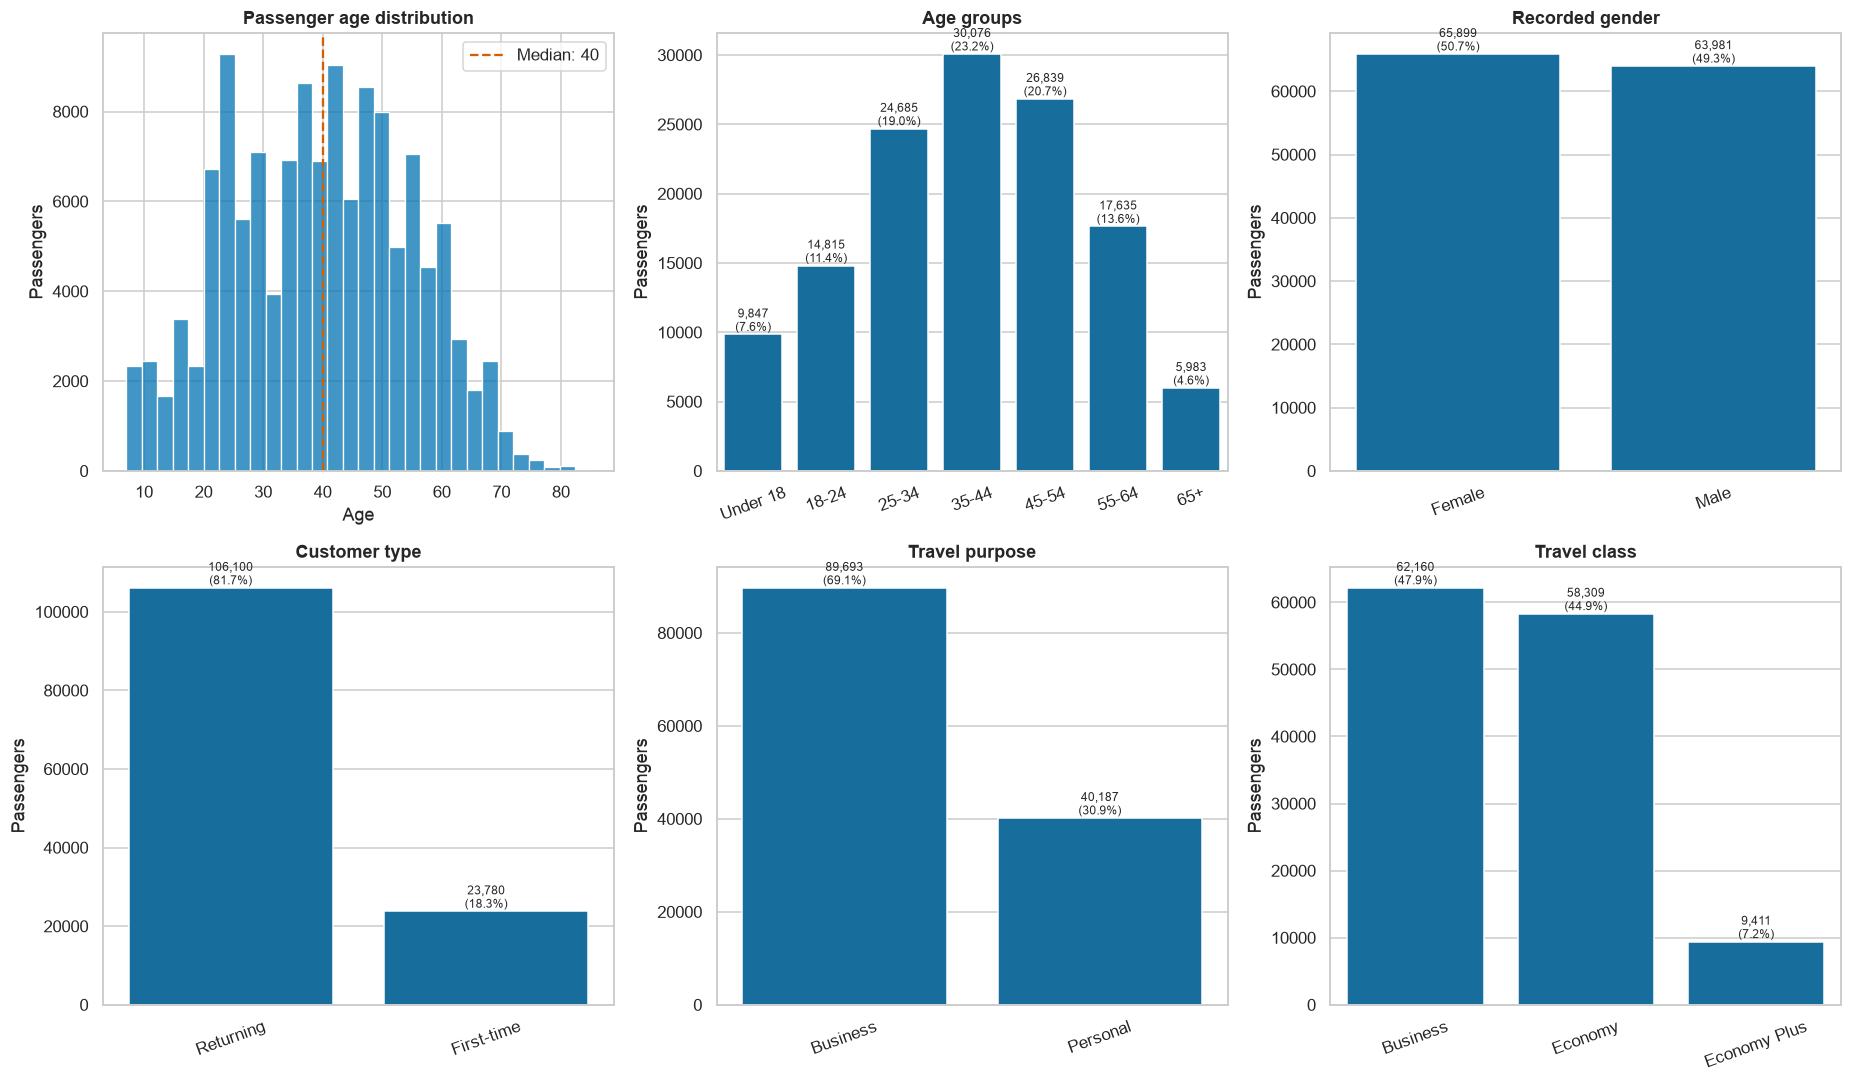

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
sns.histplot(df["age"], bins=30, color=COLORS[0], ax=axes[0, 0])
axes[0, 0].axvline(df["age"].median(), color=COLORS[3], linestyle="--", label=f"Median: {df['age'].median():.0f}")
axes[0, 0].set(title="Passenger age distribution", xlabel="Age", ylabel="Passengers")
axes[0, 0].legend()
count_plot(axes[0, 1], "age_group", "Age groups", ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"] )
count_plot(axes[0, 2], "gender", "Recorded gender", ["Female", "Male"] )
count_plot(axes[1, 0], "customer_type", "Customer type", ["Returning", "First-time"] )
count_plot(axes[1, 1], "travel_type", "Travel purpose", ["Business", "Personal"] )
count_plot(axes[1, 2], "travel_class", "Travel class", ["Business", "Economy", "Economy Plus"] )
plt.tight_layout()
plt.show()

In [6]:
age_summary = df["age"].describe(percentiles=[0.25, 0.5, 0.75]).rename({"count": "Count", "mean": "Mean", "std": "Std. dev.", "min": "Minimum", "25%": "25th percentile", "50%": "Median", "75%": "75th percentile", "max": "Maximum"})
display(age_summary.to_frame("Age").style.format("{:.1f}"))

,Age
Count,129880.0
Mean,39.4
Std. dev.,15.1
Minimum,7.0
25th percentile,27.0
Median,40.0
75th percentile,51.0
Maximum,85.0


## 4. Flight distance

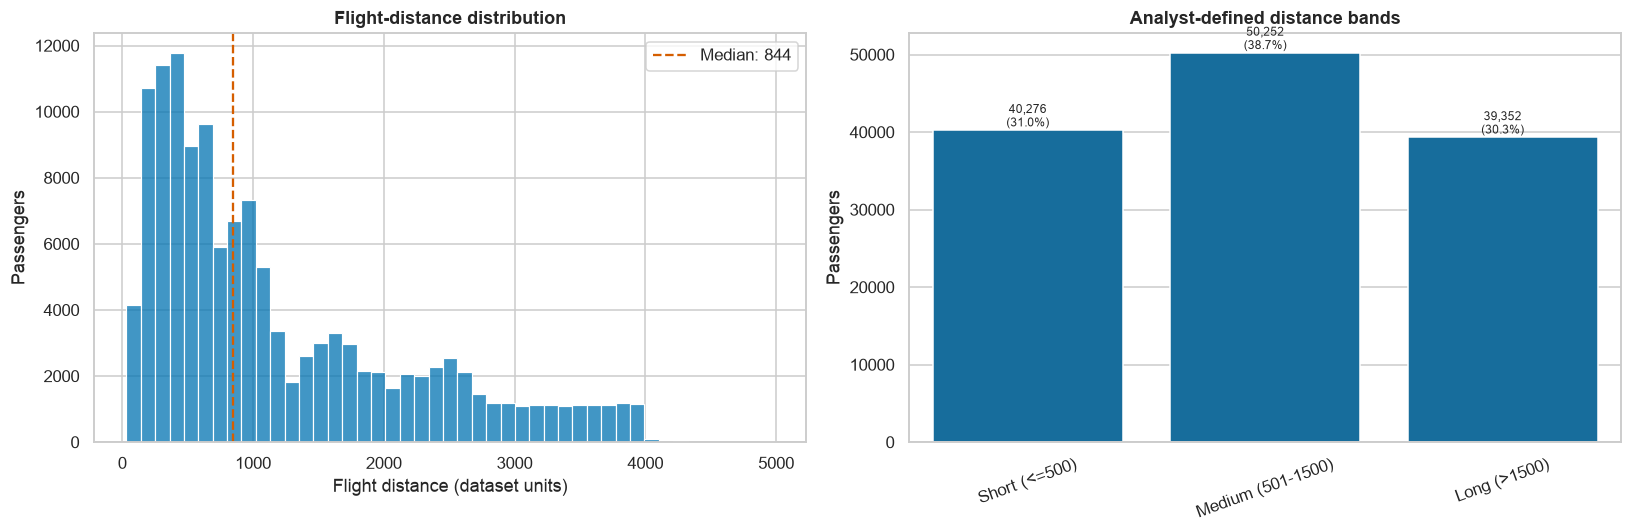

,count,mean,std,min,25%,50%,75%,95%,99%,max
flight_distance,129880.0,1190.3,997.5,31.0,414.0,844.0,1744.0,3380.0,3884.0,4983.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df["flight_distance"], bins=45, color=COLORS[0], ax=axes[0])
axes[0].axvline(df["flight_distance"].median(), color=COLORS[3], linestyle="--", label=f"Median: {df['flight_distance'].median():,.0f}")
axes[0].set(title="Flight-distance distribution", xlabel="Flight distance (dataset units)", ylabel="Passengers")
axes[0].legend()
count_plot(axes[1], "flight_distance_band", "Analyst-defined distance bands", ["Short (<=500)", "Medium (501-1500)", "Long (>1500)"] )
plt.tight_layout()
plt.show()

display(df[["flight_distance"]].describe(percentiles=[.25, .5, .75, .95, .99]).T.style.format("{:.1f}"))

## 5. Departure and arrival delays

The full delay values remain in the data. To keep the central distribution readable, the histograms below stop at each variable's 99th percentile. Delay-band charts include all observations, including the `Missing` arrival category.

,count,mean,std,min,25%,50%,75%,95%,99%,max,missing
departure_delay,129880.0,14.7,38.1,0.0,0.0,0.0,12.0,77.0,180.0,1592.0,0.0
arrival_delay,129487.0,15.1,38.5,0.0,0.0,0.0,13.0,78.0,182.0,1584.0,393.0


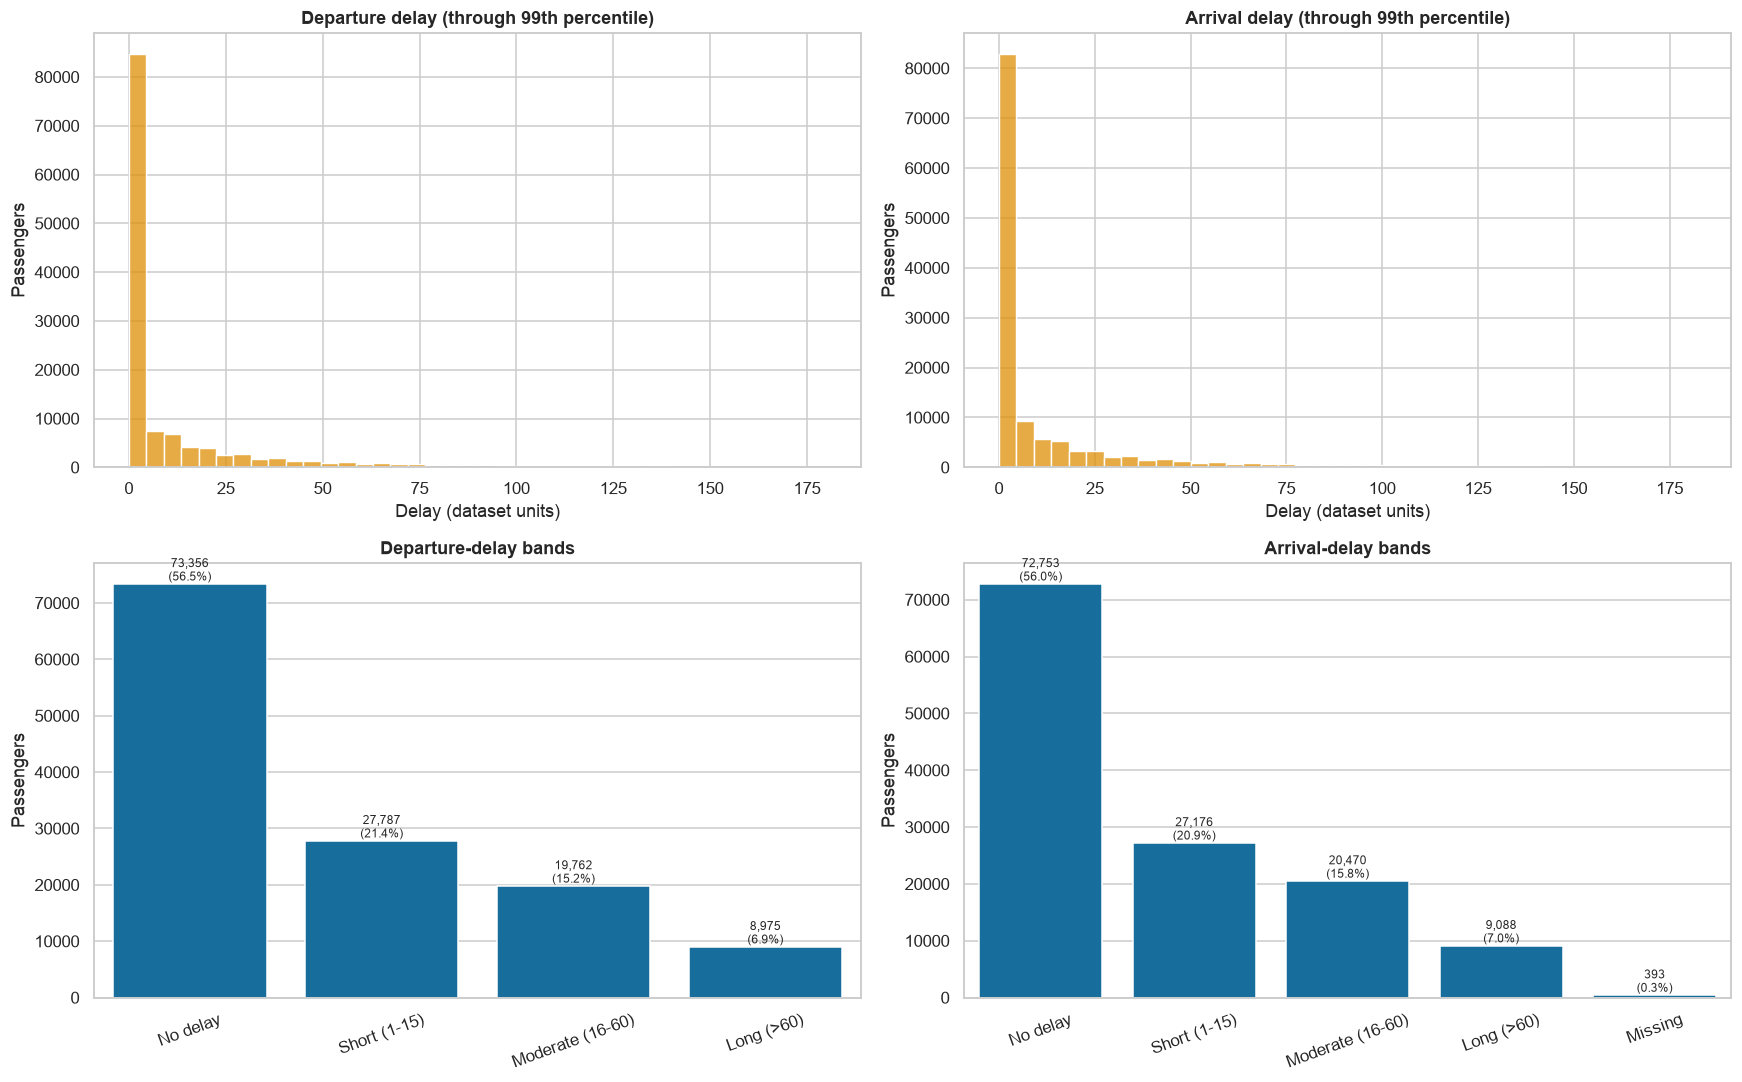

,Passengers
Arrival delay missing,393
Any delay >180,"1,457"
Any delay >720,19


In [8]:
delay_summary = df[["departure_delay", "arrival_delay"]].describe(percentiles=[.25, .5, .75, .95, .99]).T
delay_summary["missing"] = df[["departure_delay", "arrival_delay"]].isna().sum()
display(delay_summary.style.format("{:.1f}"))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, column, title in [
    (axes[0, 0], "departure_delay", "Departure delay (through 99th percentile)"),
    (axes[0, 1], "arrival_delay", "Arrival delay (through 99th percentile)"),
]:
    limit = df[column].quantile(.99)
    sns.histplot(df.loc[df[column].le(limit), column], bins=40, color=COLORS[1], ax=ax)
    ax.set(title=title, xlabel="Delay (dataset units)", ylabel="Passengers")
count_plot(axes[1, 0], "departure_delay_band", "Departure-delay bands", ["No delay", "Short (1-15)", "Moderate (16-60)", "Long (>60)"] )
count_plot(axes[1, 1], "arrival_delay_band", "Arrival-delay bands", ["No delay", "Short (1-15)", "Moderate (16-60)", "Long (>60)", "Missing"] )
plt.tight_layout()
plt.show()

delay_flags = pd.Series({
    "Arrival delay missing": df["arrival_delay_missing"].sum(),
    "Any delay >180": df["extreme_delay_over_180"].sum(),
    "Any delay >720": df["extreme_delay_over_720"].sum(),
}, name="Passengers")
display(delay_flags.to_frame().style.format("{:,}"))

## 6. Individual service ratings

Each row in the heatmap is a separate univariate rating distribution. Percentages exclude zero ratings through the cleaned fields. The missing-count chart makes those exclusions visible.

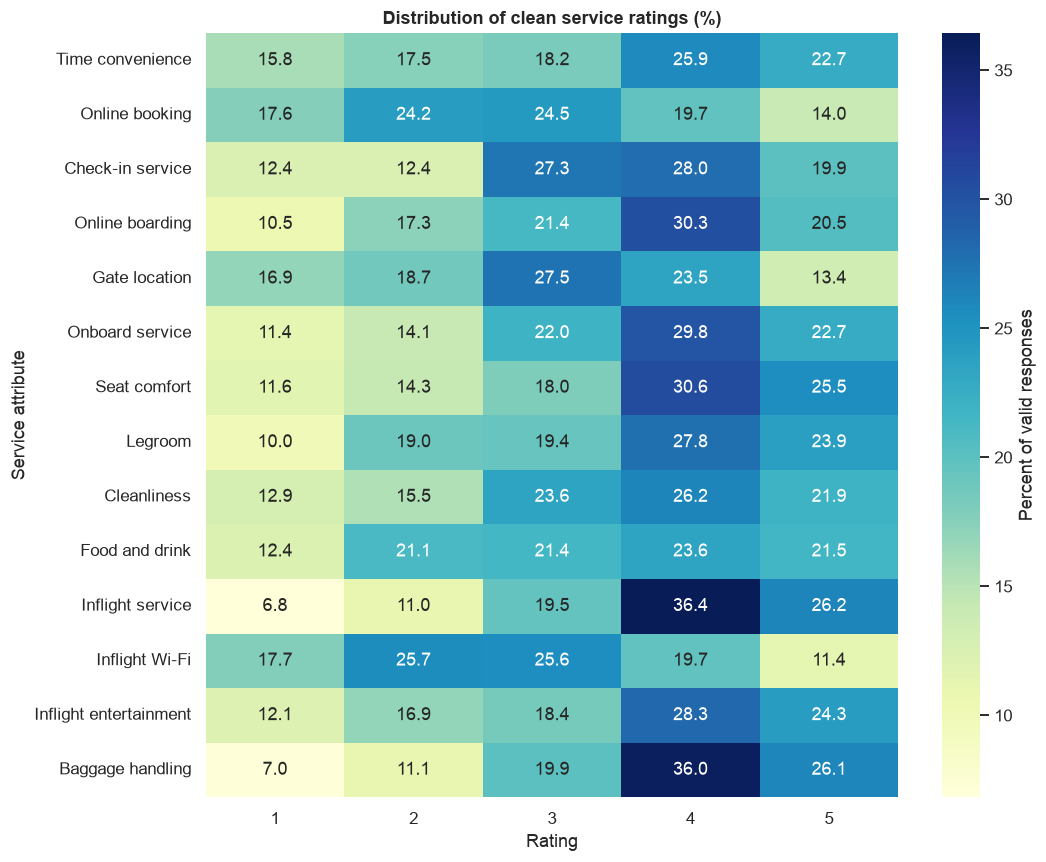

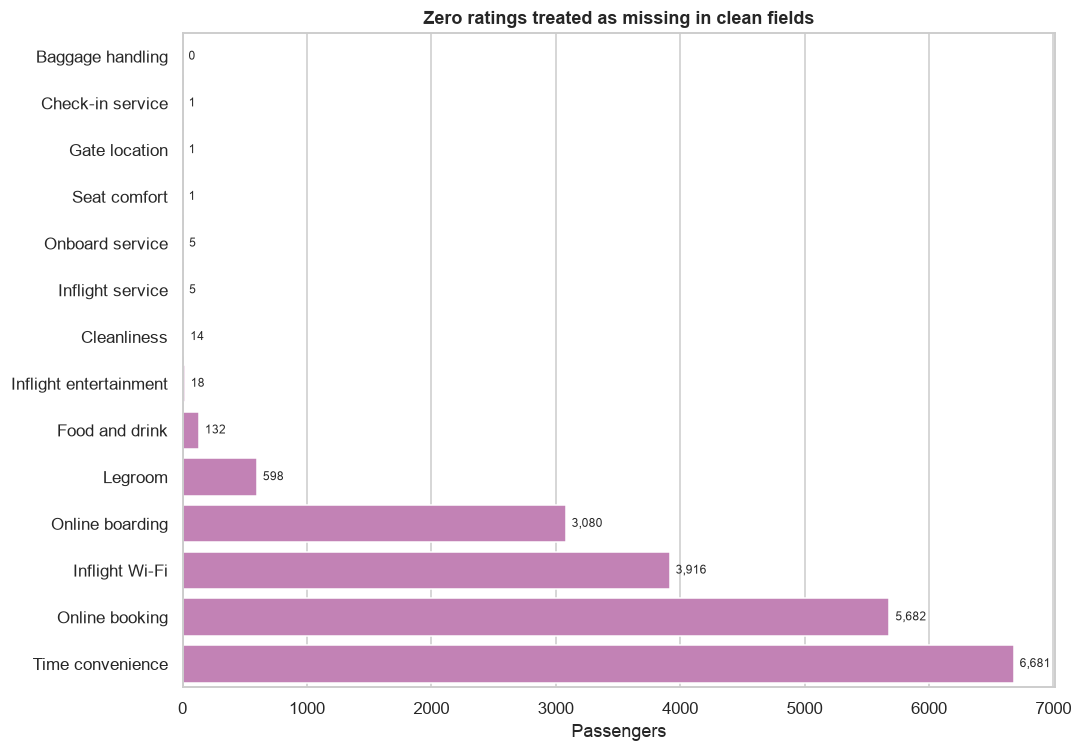

In [9]:
rating_labels = {
    "time_convenience_rating_clean": "Time convenience",
    "online_booking_rating_clean": "Online booking",
    "checkin_service_rating_clean": "Check-in service",
    "online_boarding_rating_clean": "Online boarding",
    "gate_location_rating_clean": "Gate location",
    "onboard_service_rating_clean": "Onboard service",
    "seat_comfort_rating_clean": "Seat comfort",
    "legroom_rating_clean": "Legroom",
    "cleanliness_rating_clean": "Cleanliness",
    "food_drink_rating_clean": "Food and drink",
    "inflight_service_rating_clean": "Inflight service",
    "inflight_wifi_rating_clean": "Inflight Wi-Fi",
    "inflight_entertainment_rating_clean": "Inflight entertainment",
    "baggage_handling_rating_clean": "Baggage handling",
}
rating_pct = pd.DataFrame({
    label: df[column].value_counts(normalize=True).reindex(range(1, 6), fill_value=0) * 100
    for column, label in rating_labels.items()
}).T
rating_pct.columns.name = "Rating"

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rating_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Percent of valid responses"}, ax=ax)
ax.set(title="Distribution of clean service ratings (%)", xlabel="Rating", ylabel="Service attribute")
plt.tight_layout()
plt.show()

rating_missing = df[list(rating_labels)].isna().sum().rename(index=rating_labels).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=rating_missing.values, y=rating_missing.index, color=COLORS[4], ax=ax)
ax.set(title="Zero ratings treated as missing in clean fields", xlabel="Passengers", ylabel="")
for patch in ax.patches:
    ax.text(patch.get_width(), patch.get_y() + patch.get_height()/2, f"  {int(patch.get_width()):,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
rating_summary = pd.DataFrame({
    "Valid responses": df[list(rating_labels)].count(),
    "Missing/zero": df[list(rating_labels)].isna().sum(),
    "Mean": df[list(rating_labels)].mean(),
    "Median": df[list(rating_labels)].median(),
}).rename(index=rating_labels).sort_values("Mean")
display(rating_summary.style.format({"Valid responses": "{:,}", "Missing/zero": "{:,}", "Mean": "{:.2f}", "Median": "{:.1f}"}))

,Valid responses,Missing/zero,Mean,Median
Inflight Wi-Fi,"125,964","3,916",2.81,3.0
Online booking,"124,198","5,682",2.88,3.0
Gate location,"129,879",1,2.98,3.0
Food and drink,"129,748",132,3.21,3.0
Time convenience,"123,199","6,681",3.22,3.0
Cleanliness,"129,866",14,3.29,3.0
Check-in service,"129,879",1,3.31,3.0
Online boarding,"126,800","3,080",3.33,4.0
Inflight entertainment,"129,862",18,3.36,4.0
Legroom,"129,282",598,3.37,4.0


## 7. Composite experience scores

These zero-excluded composites summarize related service attributes. The core service score—cleanliness, seat comfort, and onboard service—is especially relevant to the first hypothesis.

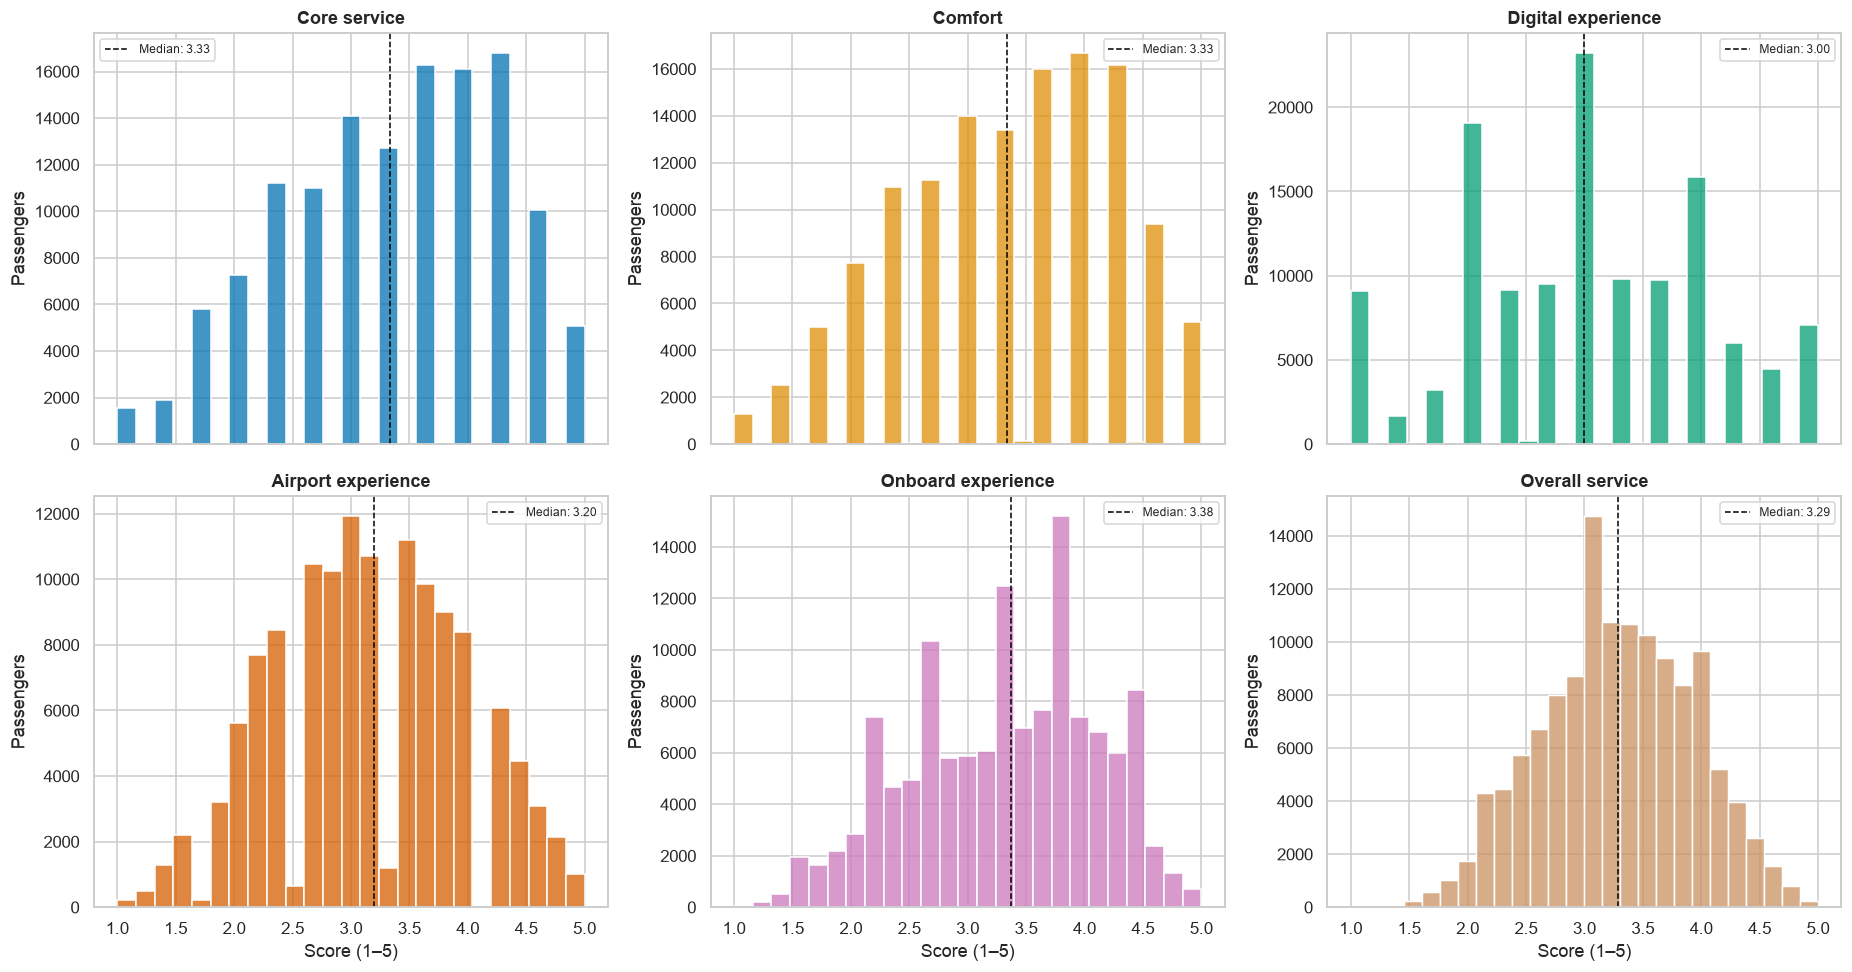

,count,mean,std,min,25%,50%,75%,max
Core service,129880.00,3.37,0.96,1.00,2.67,3.33,4.00,5.00
Comfort,129880.00,3.37,0.96,1.00,2.67,3.33,4.00,5.00
Digital experience,128277.00,3.01,1.06,1.00,2.00,3.00,4.00,5.00
Airport experience,129880.00,3.15,0.81,1.00,2.60,3.20,3.80,5.00
Onboard experience,129880.00,3.31,0.80,1.00,2.75,3.38,4.00,5.00
Overall service,129880.00,3.28,0.65,1.14,2.79,3.29,3.75,5.00


In [11]:
composites = {
    "core_service_score_clean": "Core service",
    "comfort_score_clean": "Comfort",
    "digital_experience_score_clean": "Digital experience",
    "airport_experience_score_clean": "Airport experience",
    "onboard_experience_score_clean": "Onboard experience",
    "overall_service_score_clean": "Overall service",
}
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
for ax, (column, label), color in zip(axes.flat, composites.items(), COLORS):
    sns.histplot(df[column], bins=25, color=color, ax=ax)
    median = df[column].median()
    ax.axvline(median, color="black", linestyle="--", linewidth=1, label=f"Median: {median:.2f}")
    ax.set(title=label, xlabel="Score (1–5)", ylabel="Passengers")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

composite_summary = df[list(composites)].describe(percentiles=[.25, .5, .75]).T.rename(index=composites)
display(composite_summary.style.format("{:.2f}"))

## 8. Univariate findings

In [12]:
service_means = df[list(rating_labels)].mean().rename(index=rating_labels).sort_values()
findings = f"""
- **Satisfaction:** {df['is_satisfied'].mean():.1%} of passengers are classified as satisfied; the remaining {1-df['is_satisfied'].mean():.1%} are neutral or dissatisfied.
- **Age:** The median passenger age is {df['age'].median():.0f}, with a range from {df['age'].min()} to {df['age'].max()}.
- **Sample composition:** Returning customers account for {(df['customer_type'] == 'Returning').mean():.1%}; business travel accounts for {(df['travel_type'] == 'Business').mean():.1%}.
- **Class:** Business and Economy dominate the sample; Economy Plus represents {(df['travel_class'] == 'Economy Plus').mean():.1%}.
- **Delays:** {(df['departure_delay'] == 0).mean():.1%} have no departure delay. Delay distributions are strongly right-skewed, with {int(df['extreme_delay_over_720'].sum()):,} records above 720 dataset units.
- **Service ratings:** {service_means.index[0]} has the lowest clean mean ({service_means.iloc[0]:.2f}), while {service_means.index[-1]} has the highest ({service_means.iloc[-1]:.2f}).
- **Missingness:** Arrival delay is missing for {int(df['arrival_delay_missing'].sum()):,} records ({df['arrival_delay_missing'].mean():.2%}). Clean rating missingness is concentrated in optional/digital service fields.

These are descriptive findings only. Relationships with satisfaction will be assessed during bivariate and hypothesis testing.
"""
display(Markdown(findings))


- **Satisfaction:** 43.4% of passengers are classified as satisfied; the remaining 56.6% are neutral or dissatisfied.
- **Age:** The median passenger age is 40, with a range from 7 to 85.
- **Sample composition:** Returning customers account for 81.7%; business travel accounts for 69.1%.
- **Class:** Business and Economy dominate the sample; Economy Plus represents 7.2%.
- **Delays:** 56.5% have no departure delay. Delay distributions are strongly right-skewed, with 19 records above 720 dataset units.
- **Service ratings:** Inflight Wi-Fi has the lowest clean mean (2.81), while Inflight service has the highest (3.64).
- **Missingness:** Arrival delay is missing for 393 records (0.30%). Clean rating missingness is concentrated in optional/digital service fields.

These are descriptive findings only. Relationships with satisfaction will be assessed during bivariate and hypothesis testing.
